In [18]:
from pathlib import Path
import sys
import time
import json
import joblib

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

In [19]:
DATA = PROJECT_ROOT / "data" / "processed"

X_train = pd.read_csv(DATA / "X_train_scaled.csv")

X_test = pd.read_csv(DATA / "X_test_scaled.csv")

y_train = pd.read_csv(DATA / "y_train.csv")["Label"]

y_test = pd.read_csv(DATA / "y_test.csv")["Label"]

label_encoder = joblib.load(DATA / "label_encoder.pkl")

print(X_train.shape)

print(X_test.shape)

(64000, 20)
(16000, 20)


In [20]:
rf = RandomForestClassifier(

    n_estimators=300,

    random_state=42,

    n_jobs=-1
)

start = time.time()

rf.fit(
    X_train,
    y_train
)

training_time = time.time() - start

print()

print("Training Time :", training_time)


Training Time : 64.96270418167114


In [21]:
start = time.time()

y_pred = rf.predict(X_test)

prediction_time = time.time() - start

print()

print("Prediction Time :", prediction_time)


Prediction Time : 0.5009396076202393


In [22]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("="*60)

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 :", f1)

print("="*60)

Accuracy : 0.981875
Precision : 0.9819618180145503
Recall : 0.981875
F1 : 0.9818787738755193


In [23]:
report = classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
)

print(report)

              precision    recall  f1-score   support

      AM-DSB       1.00      1.00      1.00      2000
      AM-SSB       0.97      1.00      0.98      2000
        BPSK       0.98      0.98      0.98      2000
       CPFSK       0.97      0.97      0.97      2000
        GFSK       0.99      0.98      0.98      2000
        PAM4       0.99      0.97      0.98      2000
       QAM64       0.99      0.98      0.99      2000
        QPSK       0.97      0.97      0.97      2000

    accuracy                           0.98     16000
   macro avg       0.98      0.98      0.98     16000
weighted avg       0.98      0.98      0.98     16000



In [24]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm_df = pd.DataFrame(
    cm,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

cm_df

,AM-DSB,AM-SSB,BPSK,CPFSK,GFSK,PAM4,QAM64,QPSK
AM-DSB,1998,0,1,0,1,0,0,0
AM-SSB,0,1999,0,0,0,0,1,0
BPSK,0,18,1961,0,0,21,0,0
CPFSK,0,0,0,1943,21,0,0,36
GFSK,0,0,0,26,1964,0,0,10
PAM4,0,14,36,0,0,1950,0,0
QAM64,0,14,3,0,0,1,1958,24
QPSK,0,14,1,32,3,1,12,1937


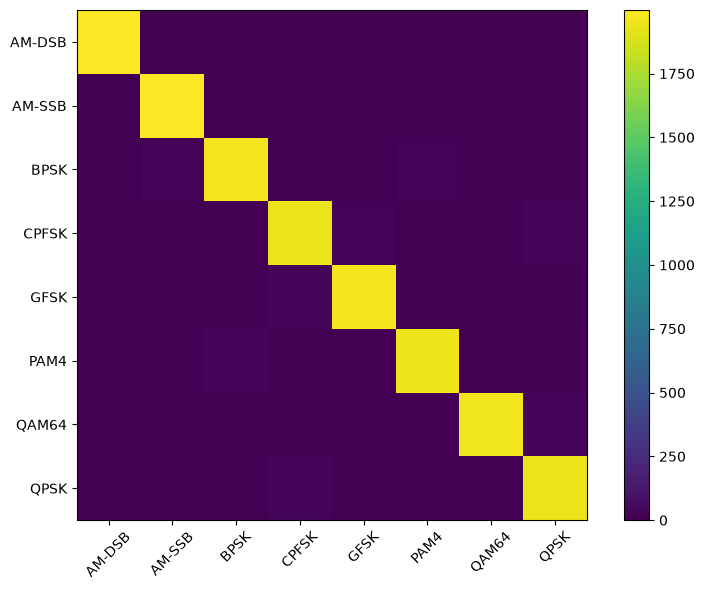

In [25]:
plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=45
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

plt.colorbar()

plt.tight_layout()

plt.show()

In [26]:
per_class = cm.diagonal() / cm.sum(axis=1)

per_class_df = pd.DataFrame({

    "Modulation":label_encoder.classes_,

    "Accuracy":per_class

})

per_class_df

,Modulation,Accuracy
0,AM-DSB,0.9990
1,AM-SSB,0.9995
2,BPSK,0.9805
3,CPFSK,0.9715
4,GFSK,0.9820
5,PAM4,0.9750
6,QAM64,0.9790
7,QPSK,0.9685


In [27]:
importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance

,Feature,Importance
13,M20,0.109759
1,AmplitudeStd,0.089658
4,FrequencyStd,0.088559
7,SigmaZ2,0.085903
3,PhaseStd,0.073004
6,SigmaDP,0.069383
8,BlindSNR,0.051614
10,SpectralEntropy,0.051402
14,C42,0.043254
18,R4,0.041009


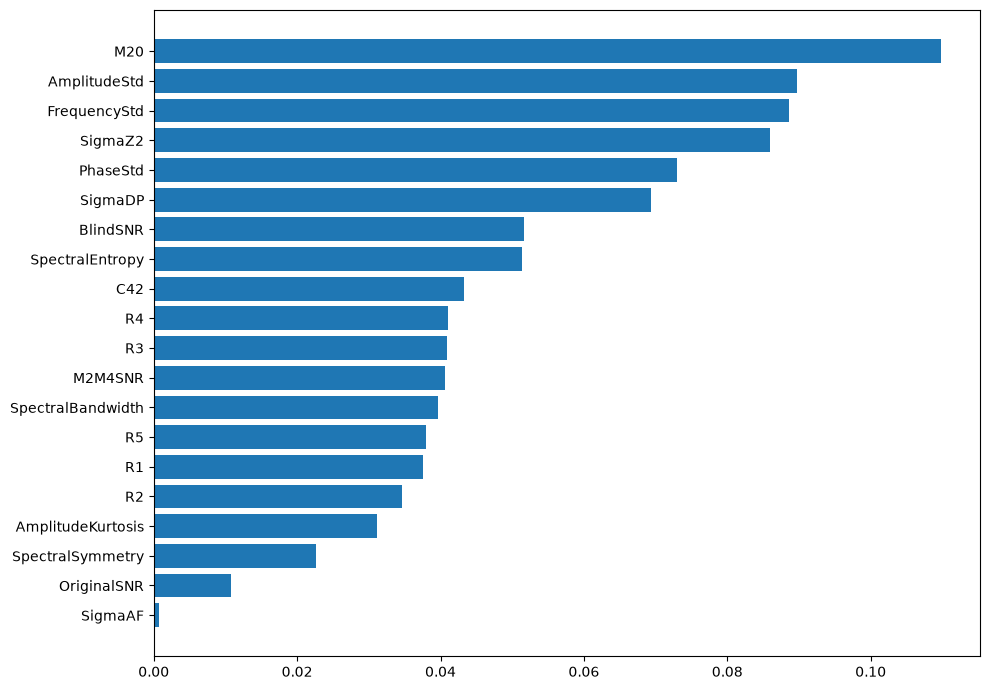

In [28]:
plt.figure(figsize=(10,7))

plt.barh(

    importance["Feature"],

    importance["Importance"]

)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [29]:
original = pd.read_csv(DATA / "feature_dataset_clean.csv")

test_index = y_test.index

snr = original.loc[test_index, "OriginalSNR"]

results = pd.DataFrame({

    "Actual":y_test,

    "Predicted":y_pred,

    "SNR":snr

})

snr_accuracy = results.groupby("SNR").apply(

    lambda x:(x.Actual==x.Predicted).mean()

)

snr_accuracy

SNR
0     0.97600
2     0.98650
4     0.98100
6     0.98400
8     0.98075
10    0.98500
12    0.98350
14    0.97600
16    0.97700
dtype: float64

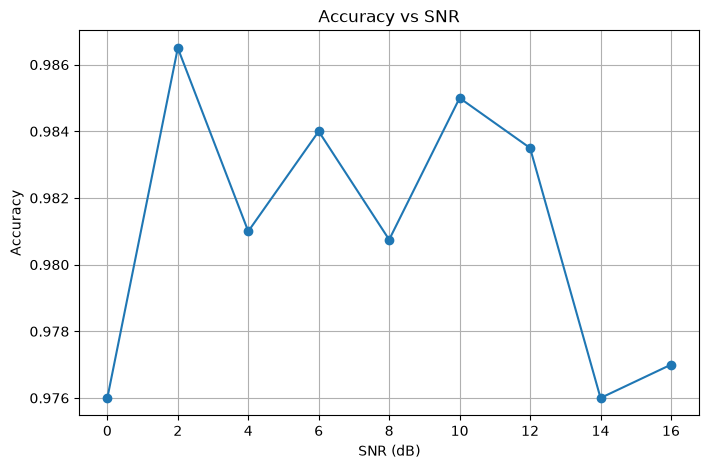

In [30]:
plt.figure(figsize=(8,5))

plt.plot(

    snr_accuracy.index,

    snr_accuracy.values,

    marker="o"

)

plt.grid(True)

plt.xlabel("SNR (dB)")

plt.ylabel("Accuracy")

plt.title("Accuracy vs SNR")

plt.show()

In [31]:
UNKNOWN_THRESHOLD = 0.75

def predict_signal(sample):

    prob = rf.predict_proba(sample)

    confidence = np.max(prob)

    prediction = np.argmax(prob)

    if confidence < UNKNOWN_THRESHOLD:

        return "Unknown", confidence

    return label_encoder.inverse_transform([prediction])[0], confidence

In [32]:
prediction, confidence = predict_signal(

    X_test.iloc[[0]]

)

print(prediction)

print(confidence)

PAM4
1.0


In [33]:
MODEL = PROJECT_ROOT / "models"

MODEL.mkdir(

    parents=True,

    exist_ok=True

)

joblib.dump(

    rf,

    MODEL / "random_forest.pkl"

)

metadata = {

    "accuracy":float(accuracy),

    "precision":float(precision),

    "recall":float(recall),

    "f1":float(f1),

    "training_time":training_time,

    "prediction_time":prediction_time,

    "threshold":UNKNOWN_THRESHOLD

}

with open(

    MODEL / "random_forest_metadata.json",

    "w"

) as f:

    json.dump(

        metadata,

        f,

        indent=4

    )

print("Model Saved Successfully")

Model Saved Successfully


In [34]:
REPORT = PROJECT_ROOT / "results" / "reports"

REPORT.mkdir(

    parents=True,

    exist_ok=True

)

importance.to_csv(

    REPORT / "feature_importance.csv",

    index=False

)

per_class_df.to_csv(

    REPORT / "per_class_accuracy.csv",

    index=False

)

cm_df.to_csv(

    REPORT / "confusion_matrix.csv"

)

print("Reports Saved")

Reports Saved
